In [2]:
import numpy as np
import os
import xarray as xr
import glob
import matplotlib.pyplot as plt
import pandas as pd
import datetime
from matplotlib.colors import BoundaryNorm
import matplotlib.colors as mcolors
import dask.array as da
import pickle
from scipy.stats import t
import matplotlib.ticker as ticker
from matplotlib.cm import get_cmap
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.ticker import FuncFormatter
from datetime import timedelta
from matplotlib.patches import Rectangle
from cartopy.mpl.gridliner import LongitudeFormatter, LatitudeFormatter
import tkinter as tk
from tkinter import ttk
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib import colormaps
from matplotlib.patches import Rectangle
import numpy as np
import xarray as xr
import matplotlib
import matplotlib.cm as cm
import warnings
%matplotlib inline

In [3]:
## reading in cloud information

path = '/home/annierosen16/data/era5sgp/era5_sl_blheight_and_cloudbase'

files = sorted(glob.glob(f"{path}/*.nc"))

bl = xr.open_mfdataset(files, combine="by_coords")

bl['valid_time'] = bl['valid_time'] - pd.Timedelta(hours=6)

bl = bl.rename({"valid_time": "time"})

bl = bl.where(bl['time.month'] != 4, drop=True)

In [4]:
## reading in APEs information

with open('/home/annierosen16/master_1979_2025.pkl', 'rb') as f:
    
    master = pickle.load(f)
    
master['date'] = pd.to_datetime(master['date']).dt.date

In [5]:
bldf = bl[['cbh', 'blh']].to_dataframe().reset_index()

bldf['date'] = pd.to_datetime(bldf['time']).dt.date

bldf = bldf.drop(columns=['number', 'expver'])

In [6]:
blh = bldf.groupby(['date', 'latitude', 'longitude'])['blh'].apply(lambda x: x.values).reset_index()

print("blh complete")

cbh = bldf.groupby(['date', 'latitude', 'longitude'])['cbh'].apply(lambda x: x.values).reset_index()

print("cbh complete")

blh complete
cbh complete


In [7]:
master_with_bl = (
    master.merge(blh, on=['date', 'latitude', 'longitude'], how='inner')
          .merge(cbh, on=['date', 'latitude', 'longitude'], how='inner')
)

print(master_with_bl.shape)

master_with_bl = master_with_bl[master_with_bl["blh"].apply(lambda x: isinstance(x, (list, np.ndarray)) and len(x) == 24)]

print(master_with_bl.shape)

(10908747, 24)
(10837448, 24)


In [8]:
dryapes = master_with_bl[master_with_bl['dryape']==True].reset_index(drop=True)

wetapes = master_with_bl[master_with_bl['wetape']==True].reset_index(drop=True)

In [9]:
# blh

dry_blh_array = np.stack(dryapes['blh'].values)

wet_blh_array = np.stack(wetapes['blh'].values)

dry_blh_composite = np.nanmean(dry_blh_array, axis=0) / 1000

wet_blh_composite = np.nanmean(wet_blh_array, axis=0) / 1000

dry_blh_sem = np.nanstd(dry_blh_array, axis=0) / np.sqrt(np.sum(~np.isnan(dry_blh_array), axis=0)) / 1000

wet_blh_sem = np.nanstd(wet_blh_array, axis=0) / np.sqrt(np.sum(~np.isnan(wet_blh_array), axis=0)) / 1000

dry_blh_std = np.nanstd(dry_blh_array, axis=0) / 1000

wet_blh_std = np.nanstd(wet_blh_array, axis=0) / 1000

low_iqr_dry_blh = np.percentile(dry_blh_array, 25) / 1000



# cbh

dry_cbh_array = np.stack(dryapes['cbh'].values)

wet_cbh_array = np.stack(wetapes['cbh'].values)

dry_cbh_composite = np.nanmean(dry_cbh_array, axis=0) / 1000

wet_cbh_composite = np.nanmean(wet_cbh_array, axis=0) / 1000

dry_cbh_sem = np.nanstd(dry_cbh_array, axis=0) / np.sqrt(np.sum(~np.isnan(dry_cbh_array), axis=0)) / 1000

wet_cbh_sem = np.nanstd(wet_cbh_array, axis=0) / np.sqrt(np.sum(~np.isnan(wet_cbh_array), axis=0)) / 1000

dry_cbh_std = np.nanstd(dry_cbh_array, axis=0) / 1000

wet_cbh_std = np.nanstd(wet_cbh_array, axis=0) / 1000

In [11]:
with open('/home/annierosen16/diurnal_blh_1979_2025.pkl', 'wb') as f:
    pickle.dump({
        'dry_mean': dry_blh_composite,
        'dry_std':  dry_blh_std,
        'dry_se':   dry_blh_sem,
        'wet_mean': wet_blh_composite,
        'wet_std':  wet_blh_std,
        'wet_se':   wet_blh_sem,
    }, f)

with open('/home/annierosen16/diurnal_cbh_1979_2025.pkl', 'wb') as f:
    pickle.dump({
        'dry_mean': dry_cbh_composite,
        'dry_std':  dry_cbh_std,
        'dry_se':   dry_cbh_sem,
        'wet_mean': wet_cbh_composite,
        'wet_std':  wet_cbh_std,
        'wet_se':   wet_cbh_sem,
    }, f)

print("BLH and CBH files saved.")

BLH and CBH files saved.


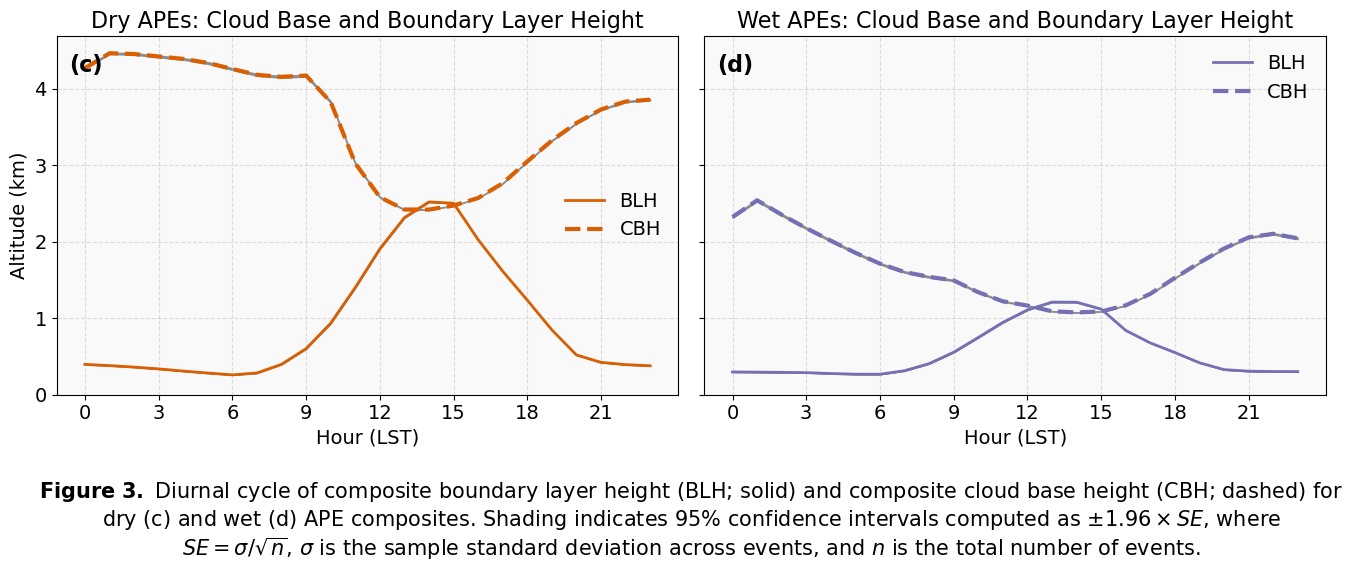

In [12]:
hours = list(range(24))

# Colors (muted palette)
dry_color = '#d95f02'

wet_color = '#7570b3'

# Increase global font scaling (but NOT titles)
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14
})

fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

# --- Dry APE ---

ci_constant = 1.96

cbh_lw = 3

axs[0].plot(hours, dry_blh_composite, label='BLH', color=dry_color, lw=2)

axs[0].fill_between(hours,
                    dry_blh_composite - (ci_constant*dry_blh_sem),
                    dry_blh_composite + (ci_constant*dry_blh_sem),
                    color='grey', alpha=0.8)

axs[0].plot(hours, dry_cbh_composite, label='CBH',
            color=dry_color, lw=cbh_lw, linestyle='--')
axs[0].fill_between(hours,
                    dry_cbh_composite - (ci_constant*dry_cbh_sem),
                    dry_cbh_composite + (ci_constant*dry_cbh_sem),
                    color='grey', alpha=0.8)

axs[0].set_title('Dry APEs: Cloud Base and Boundary Layer Height', fontsize=16)  # unchanged
axs[0].set_xlabel('Hour (LST)')
axs[0].set_ylabel('Altitude (km)')
axs[0].grid(True, linestyle='--', alpha=0.4)
axs[0].legend(frameon=False)
axs[0].set_facecolor('#f9f9f9')

# --- Wet APE ---
axs[1].plot(hours, wet_blh_composite, label='BLH', color=wet_color, lw=2)
axs[1].fill_between(hours,
                    wet_blh_composite - (ci_constant*wet_blh_sem),
                    wet_blh_composite + (ci_constant*wet_blh_sem),
                    color='grey', alpha=0.8)

axs[1].plot(hours, wet_cbh_composite, label='CBH',
            color=wet_color, lw=cbh_lw, linestyle='--')
axs[1].fill_between(hours,
                    wet_cbh_composite - (ci_constant*wet_cbh_sem),
                    wet_cbh_composite + (ci_constant*wet_cbh_sem),
                    color='grey', alpha=0.8)

axs[1].set_title('Wet APEs: Cloud Base and Boundary Layer Height', fontsize=16)  # unchanged
axs[1].set_xlabel('Hour (LST)')
axs[1].grid(True, linestyle='--', alpha=0.4)
axs[1].legend(frameon=False)
axs[1].set_facecolor('#f9f9f9')

# Formatting
for ax in axs.flat:
    ax.set_xticks(hours[::3])
    ax.tick_params(axis='both')

# Panel labels (slightly larger)
panel_labels = ["(c)", "(d)"]
for ax, label in zip(axs, panel_labels):
    ax.text(
        0.02, 0.95,
        label,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=16,
        fontweight="bold"
    )

# Caption (larger + slightly higher)
caption = (
    r"$\bf{Figure\ 3.}$ "
    "Diurnal cycle of composite boundary layer height (BLH; solid) and composite cloud base height "
    "(CBH; dashed) for dry (c) and wet (d) APE composites. Shading indicates 95% confidence intervals computed as "
    r"$\pm 1.96 \times SE$, where $SE = \sigma/\sqrt{n}$, $\sigma$ is the sample standard deviation "
    "across events, and $n$ is the total number of events."
)

plt.tight_layout(rect=[0.03, 0.20, 1, 1])

# Now get updated axes positions
left  = axs[0].get_position().x0

right = axs[1].get_position().x1

x_center = (left + right) / 2

fig.text(
    x_center, 0.045,
    caption,
    ha="center",
    va="bottom",
    fontsize=15,
    wrap=True
)

plt.ylim(0)

plt.show()